In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.mkdir('static') if not os.path.exists('static') else None
DPI = 100

In [ ]:
def xdot(x,dt):
  xdot = (x[1:]-x[:-1])/dt
  xdot = torch.cat([xdot,xdot[-1:]],axis = 0)
  return xdot

def x_iter(x,xdot,dt):
  x += xdot*dt
  return x

In [ ]:
def lagrangian_freebody(x, vel, m=1, g=1):
    T = .5*m*vel**2
    V = 0*x
    return T, V

def action(x,dt):
  vel = xdot(x,dt)
  T,V = lagrangian_freebody(x,vel)
  return T.sum() - V.sum()

def action2(xi,vel,dt):
    x = torch.zeros(len(vel)+1)
    x[0].data = xi
    x[1:] = x[:-1] + vel*dt
    T, V = lagrangian_freebody(x, vel)
    return T.sum()-V.sum()



In [ ]:
import torch
def get_path_between(x, steps=1000, step_size=1e-1, dt=1, num_prints=8, num_stashes=80):
    t = np.linspace(0, len(x)-1, len(x)) * dt
    print_on = np.linspace(0,int(np.sqrt(steps)),num_prints).astype(np.int32)**2
    stash_on = np.linspace(0,int(np.sqrt(steps)),num_stashes).astype(np.int32)**2
    xs = []
    for i in range(steps):
        grad_x = torch.autograd.grad(action(x, dt), x)[0]
        grad_x[[0,-1]] *= 0
        x.data -= grad_x * step_size

        if i in print_on:
            print('step={:04d}, S={:.4e} J*s'.format(i, action(x, dt).item()))
        if i in stash_on:
            xs.append(x.clone().data.numpy())
    return t, x, np.stack(xs)

In [ ]:
import torch
def get_path_between_2(x, y, steps=1000, step_size=1e-1, dt=1, num_prints=8, num_stashes=80):
    t = np.linspace(0, len(x)-1, len(x)) * dt
    print_on = np.linspace(0,int(np.sqrt(steps)),num_prints).astype(np.int32)**2
    stash_on = np.linspace(0,int(np.sqrt(steps)),num_stashes).astype(np.int32)**2
    xs = []
    ys = []
    for i in range(steps):
        grad_x = torch.autograd.grad(action3(x,y, dt), x)[0]
        grad_y = torch.autograd.grad(action3(x,y, dt), y)[0]
        grad_x[[0,-1]] *= 0
        grad_y[[0,-1]] *= 0
        x.data -= grad_x * step_size
        y.data -= grad_y * step_size

        if i in print_on:
            print('step={:04d}, S={:.4e} J*s'.format(i, action3(x,y, dt).item()))
        if i in stash_on:
            xs.append(x.clone().data.numpy())
            ys.append(y.clone().data.numpy())
    return t, x, np.stack(xs), np.stack(ys)

In [ ]:
import torch
def get_path(x, steps=1000, step_size=1e-1, dt=1, num_prints=8, num_stashes=80):
    t = np.linspace(0, len(x)-1, len(x)) * dt
    print_on = np.linspace(0,int(np.sqrt(steps)),num_prints).astype(np.int32)**2 # print more often early in loop
    stash_on = np.linspace(0,int(np.sqrt(steps)),num_stashes).astype(np.int32)**2
    xs = []
    for i in range(steps):
      grad_a = torch.autograd.grad(action(x,dt),acc(x,dt),allow_unused=True)[0]
      accn -= grad_a*step_size
      vel = x_iter(vel,accn,dt)
      x = x_iter(x,vel,dt)
      if i in print_on:
          print('step={:04d}, S={:.4e} J*s'.format(i, action(x,dt).item()))
      if i in stash_on:
          xs.append(x.clone().data.numpy())
    return t, x, np.stack(xs)

In [ ]:
dt = 0.19
res = 1000
x0 = 1.5*torch.randn(res, requires_grad=True)
x0[0].data *= 0.0 ; x0[-1].data *= 0.0; x0[-1] += 20


t, x, xs_ncf = get_path_between(x0.clone(), steps=500000, step_size=1e-2, dt=dt)

step=0000, S=1.0397e+04 J*s
step=10201, S=4.1642e+01 J*s
step=40804, S=2.0912e+01 J*s
step=91809, S=1.3926e+01 J*s
step=163216, S=1.0431e+01 J*s
step=255025, S=8.3509e+00 J*s
step=367236, S=7.0449e+00 J*s
step=499849, S=6.2715e+00 J*s


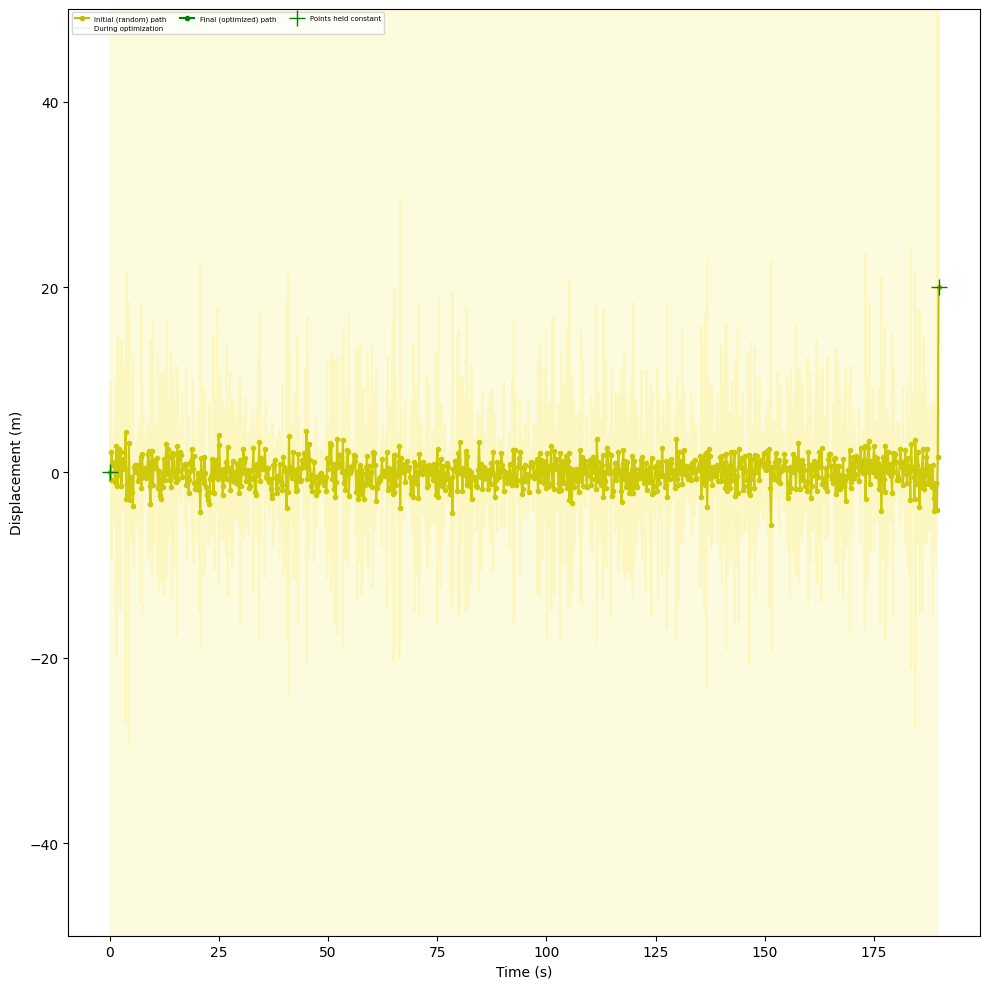

tensor(nan, grad_fn=<SelectBackward0>) tensor(nan, grad_fn=<SelectBackward0>)


In [ ]:
#plt.title('Minimizing the Action')

plt.figure(dpi=DPI,figsize=(10,10))
plt.plot(t, x0.detach().numpy(), 'y.-', label='Initial (random) path')

for i, xi in enumerate(xs_ncf):
    label = 'During optimization' if i==15 else None
    plt.plot(t, xi, alpha=0.15, color=plt.cm.viridis( 1-i/(len(xs_ncf)-1) ), label=label)
plt.plot(t, x.detach().numpy(), 'g.-', label='Final (optimized) path')
plt.plot(t[[0,-1]], x0.data[[0,-1]], 'g+', markersize=12, label='Points held constant')

ylim = (-50,50)

plt.ylim(ylim[0],ylim[1])
plt.xlabel('Time (s)') ; plt.ylabel('Displacement (m)') ; plt.legend(fontsize=5, ncol=3)
plt.tight_layout() ; plt.savefig('static/tutorial_action.png') ; plt.show()

print(x[-2],x[-1])

### Make a video of the simulation process

In [ ]:
!pip install celluloid
from celluloid import Camera
from IPython.display import HTML
from base64 import b64encode

In [ ]:
def make_video(t, xs, path, interval=60, color='black', mode='ncf', **kwargs): # xs: [time, N, 2]
    fig = plt.gcf() ; fig.set_dpi(200) ; fig.set_size_inches(3, 3)
    camera = Camera(fig)
    for i in range(len(xs) if type(xs) is list else xs.shape[0]):
        if mode == 'ncf':
            for j, xi in enumerate(xs[:i]):
                plt.plot(t, xi, alpha=0.15, color=plt.cm.viridis( 1-j/(len(xs)-1) ), label=label)
            plt.plot(t, xs[0], '.-', color=plt.cm.viridis(0.9))
        plt.plot(t[[0,-1]], xs[-1][[0,-1]], '+', color=color, markersize=16)
        plt.plot(t[:len(xs[i])], xs[i], '.-', color=color)
        plt.xlim(np.min(t)-1, np.max(t)+1) ; plt.ylim(ylim[0],ylim[1])
        plt.xticks([], []); plt.yticks([], []) ; plt.xlabel('Time (s)') ; plt.ylabel('Height (m)')
        camera.snap()
    anim = camera.animate(blit=True, interval=interval, **kwargs)
    anim.save(path) ; plt.close()

In [ ]:
xs_ncf_ = np.concatenate([xs_ncf[:1]]*20+[xs_ncf]+[xs_ncf[-1:]]*20 )
make_video(t, xs_ncf_, path='static/tutorial_ncf.mp4', color='green', interval=80)

mp4 = open('static/tutorial_ncf.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML('<video width=500 controls><source src="{}" type="video/mp4"></video>'.format(data_url))